<a href="https://colab.research.google.com/github/overcharged-coder/PollenAllergyProject/blob/main/Colab_Pollen_proj_vfinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import libraries.

In [ ]:
# ----------------------------
# Data handling & computation
# ----------------------------
import pandas as pd              # Data manipulation and tabular data structures
import numpy as np               # Numerical operations and array-based computation
import re                        # Regular expressions for text cleaning or pattern matching

# ----------------------------
# Visualization
# ----------------------------
import seaborn as sns             # Statistical data visualization
import matplotlib.pyplot as plt   # Core plotting library

# ----------------------------
# Machine learning utilities
# ----------------------------
from sklearn.model_selection import train_test_split  # Split data into train/test sets
from sklearn.preprocessing import StandardScaler      # Feature scaling (zero mean, unit variance)
from sklearn.metrics import confusion_matrix          # Model evaluation for classification

# ----------------------------
# Deep learning (Keras / TensorFlow)
# ----------------------------
from tensorflow.keras import Input                     # Explicit model input definition
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping



## Data Import and Pre-processing

### Build columns to match excel.

Link to the gsheet : [gheet link](https://docs.google.com/spreadsheets/d/17Ps1v2TcHdYxCVKH3kRHjDJBTtgGimxOwwC3d5-wJOY/edit?gid=0#gid=0)

In [ ]:
# ---------------------------------------------------------
# Feature columns (X) — grouped, one group per line
# ---------------------------------------------------------
X_cols = [
    # Weather
    "Temperature Max", "Temperature Min", "Precipitation", "Wind Speed",
    # Pollen (General)
    "Grass", "Tree", "Weed",
    # Pollen (Specific)
    "ALDER", "ASH", "BIRCH", "COTTONWOOD", "ELM", "GRAMINALES","JUNIPER", "MAPLE", "OAK", "PINE", "RAGWEED",
    # Air Quality (Summary + Pollutants)
    "Air Quality Index", "PM25", "PM10", "O3", "NO2", "SO2", "CO",
    # Lunch (Dietary)
    "Lunch-Eggs", "Lunch-Chicken", "Lunch-Mutton", "Lunch-Seafood","Lunch-Fish", "Lunch-Dairy", "Lunch-Notes",
    # Dinner (Dietary)
    "Dinner", "Dinner-Eggs", "Dinner-Chicken", "Dinner-Mutton","Dinner-Seafood", "Dinner-Fish", "Dinner-Candy", "Dinner-Dessert","Dinner-Dairy", "Dinner-Notes",
    # Particle Sensor Metrics
    "pm1p0", "pm2p5", "pm4p0", "pm10p0","nc0p5", "nc1p0", "nc2p5", "nc4p0", "nc10p0",
    # Metadata
    "typical"
]
# ---------------------------------------------------------
# Target columns (Y) — grouped, one group per line
# ---------------------------------------------------------
Y_cols = [
    # Upper Respiratory
    "Sneezing", "Runny or Stuffy Nose", "Itchy Eyes",
    # Systemic
    "Fatigue", "Yawning",
    # Skin
    "Skin Rash or Hives", "Itchy Skin",
    # Lower Respiratory
    "Cough", "Wheezing", "Difficulty Breathing",
    # Severe Reaction
    "Swelling",
]


### Load the data from CSV file in google drive.

In [ ]:
# ---------------------------------------------------------
# Load Google Sheet as CSV
# ---------------------------------------------------------
# Public Google Sheet ID
sheet_id = "1PobvEO00tl2ybrQ72h1bcRbzclyoQZJZtfdaSgS8WMw"
# Construct CSV export URL
csv_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv"
# Read data into DataFrame
df = pd.read_csv(csv_url)

# ---------------------------------------------------------
# Clean column names
# ---------------------------------------------------------
# - Collapse multiple spaces into a single space
# - Strip leading/trailing whitespace
df = df.rename(
    columns=lambda c: re.sub(r"\s+", " ", str(c)).strip()
)
# ---------------------------------------------------------
# Target (Y) variable preprocessing
# ---------------------------------------------------------
# Assumption:
#   - Y columns represent binary outcomes
#   - Blank values mean "no / false"
# Steps:
#   1. Replace empty strings with NaN
#   2. Fill NaN with 0
#   3. Convert to integer
#   4. Convert to binary (1 if >0 else 0)

df[Y_cols] = (
    df[Y_cols]
    .replace("", np.nan)
    .fillna(0)
    .astype(int)
    .gt(0)
    .astype(int)
)

# ---------------------------------------------------------
# Feature (X) and Target (Y) extraction
# ---------------------------------------------------------
# Select only requested columns
X = df[X_cols]
Y = df[Y_cols]

# ---------------------------------------------------------
# Final data preparation
# ---------------------------------------------------------
# Replace any remaining missing values with 0
# (useful for ML models that do not accept NaN)
X = X.fillna(0)
Y = Y.fillna(0)


## Nueral Network


### Standadize the features

StandardScaler() creates a normalization tool that transforms your input features so they are all on the same scale.


$$
X_{\text{scaled}} = \frac{X - \text{mean}(X)}{\text{std}(X)}
$$

It is a preprocessing step that standardizes each feature (column) so that:
*  The mean becomes 0
*   The standard deviation becomes 1

This process is called **z-score normalization**.

In [ ]:
# Normalize features for stable NN training
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
#The output would show values before after normalization

# Convert X_scaled (numpy array) into a DataFrame with "_scaled" suffix
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=[c + "_scaled" for c in X.columns]
)

# Combine original and scaled side by side
df_side_by_side = pd.concat([X, X_scaled_df], axis=1)

# Show first few rows
df_side_by_side.head()


,Temperature Max,Temperature Min,Precipitation,Wind Speed,Grass,Tree,Weed,ALDER,ASH,BIRCH,...,pm1p0_scaled,pm2p5_scaled,pm4p0_scaled,pm10p0_scaled,nc0p5_scaled,nc1p0_scaled,nc2p5_scaled,nc4p0_scaled,nc10p0_scaled,typical_scaled
0,81.6,64.8,2.6,9.1,2,1,0,0,0,0,...,1.884974,1.896071,1.825758,1.804472,1.879001,1.883056,1.884795,1.885033,1.885072,-1.392174
1,76.7,65.1,20.1,10.7,2,1,0,0,0,0,...,1.199013,1.211924,1.163936,1.149549,1.186405,1.194555,1.198924,1.199570,1.199687,-1.457851
2,81.6,64.8,2.6,9.1,2,1,0,0,0,0,...,1.884974,1.896071,1.885740,1.878074,1.879001,1.883056,1.884795,1.885033,1.885072,-0.932437
3,76.7,65.1,20.1,10.7,2,1,0,0,0,0,...,1.884974,1.896071,1.885740,1.878074,1.879001,1.883056,1.884795,1.885033,1.885072,-0.932437
4,81.6,64.8,2.6,9.1,2,1,0,0,0,0,...,0.093687,-0.072431,-0.254063,-0.293189,0.128560,0.107875,0.094765,0.092537,0.092161,-1.414066


### Training Preperation
This line splits your scaled features and labels into 80% training and 20% testing, in a reproducible way, so you can train the model on one part and evaluate it on the other.


In [ ]:

# Split train/test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)


In [ ]:
print("X       :", X.shape)
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)


X       : (76, 52)
X_train : (60, 52)
X_test  : (16, 52)


### Model Architecture


![Image1](https://drive.google.com/uc?export=view&id=1hKuqSLFCyPkmPVJuoLBTUcYlX5tWrOLl)


**1.Input Layer — size = number of features**

The model takes in one vector per sample with X_train.shape[1] values (your scaled weather, pollen, and environment features).

**2.First Hidden Layer — 30 neurons (ReLU)**
A fully connected dense layer learns nonlinear relationships from the input features; ReLU allows the model to capture complex patterns efficiently.

**3.Dropout(0.3) — regularization**
Randomly turns off 30% of neurons during training to prevent overfitting, which is especially important because your dataset is small.

**4.Second Hidden Layer — 10 neurons (ReLU) + Dropout(0.3)**
A smaller layer forces the model to compress and generalize the learned information, followed again by dropout to strengthen regularization.

**5.Output Layer — len(Y_cols) neurons (Sigmoid)**

Produces one prediction per symptom outcome (11 outputs). Sigmoid ensures each output is squashed between 0–1, matching your symptom score targets.

In [ ]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),   # ← Keras-preferred input layer
    Dense(30, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='relu'),
    Dropout(0.3),
    Dense(len(Y_cols), activation='sigmoid')
])

#### Model Output Functions

In [ ]:
for layer in model.layers:
    params = layer.get_weights()

    # Skip layers with no weights
    if len(params) == 0:
        print(f"Layer: {layer.name} has no weights.")
        print("-" * 50)
        continue

    weights, biases = params

    print(f"Layer: {layer.name}")
    print("-" * 50)
    print("Weights Shape:\n", weights.shape)
    print("Weights:\n", weights)
    print("Biases:\n", biases)
    print("*" * 50)


Layer: dense
--------------------------------------------------
Weights Shape:
 (52, 30)
Weights:
 [[ 0.03088066  0.14774385  0.06526017 ...  0.19805092  0.21227416
  -0.23428363]
 [-0.1750677  -0.09197409 -0.21476188 ...  0.06430116  0.15423626
  -0.0414878 ]
 [-0.08325709 -0.0857538  -0.20933169 ...  0.2581277  -0.22743304
   0.01649821]
 ...
 [ 0.02654856  0.22346526  0.2528528  ...  0.18566865 -0.08443163
   0.10340092]
 [ 0.02647492 -0.09508817  0.13209477 ...  0.07922852 -0.1577527
  -0.13817866]
 [ 0.23383904  0.19792065  0.19764927 ...  0.24828947 -0.06370434
  -0.07086675]]
Biases:
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
**************************************************
Layer: dropout has no weights.
--------------------------------------------------
Layer: dense_1
--------------------------------------------------
Weights Shape:
 (30, 10)
Weights:
 [[ 0.21541643 -0.25130036 -0.3039126   0.08530492 -0.2364841   0.1357823
 

### Early Stop
EarlyStopping is a callback in Keras.It is passed to model.fit(...) to control the training.If the model stops improving on some metric, stop training early so we don’t overfit or waste time.

**monitor='val_loss'**

Watch the validation loss, and decide whether things are getting better or worse based on that.
*monitor* tells EarlyStopping what to watch.

**patience=10**
patience is how many epochs we’re willing to wait without improvement. If val_loss does not improve for 10 epochs in a row, stop training.

**restore_best_weights=True**
The model might reach its best validation loss at, say, epoch 18.But training continues to 30 before EarlyStopping kicks in. If restore_best_weights=False (default), after stopping, the model keeps the weights from the last epoch (epoch 30), which might be overfitted or worse.

In [ ]:
# --- Train ---
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


### Defining the Learning Rules
**optimizer='adam'**

Use Adam to update the model weights while training. Decides how much to change each weight. Adam takes bigger steps in stable directions and smaller steps in noisy directions.

**loss='mse' (Mean Squared Error)**

Loss is the main quantity the model tries to minimize.

$$
\text{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2
$$



**metrics=['mae'] (Mean Absolute Error)**

Metrics are extra things you want printed and tracked, but they are not directly minimized (only the loss is).

$$
\text{MAE} = \frac{1}{N} \sum_{i=1}^{N} \lvert y_i - \hat{y}_i \rvert
$$




In [ ]:
# --- Compile ---
model.compile(
    optimizer='adam',
    loss='mse',     # mean squared error since this is regression (symptom intensity)
    metrics=['mae'] # mean absolute error
)


### Model Training Configuration (model.fit parameters)

**X_train**: Training feature matrix containing the input variables used by the model(e.g., environmental, pollen, air quality, or behavioral features)

**y_train**: Training target matrix containing the labels the model is trying to predict (e.g., symptom presence or severity)

**validation_split**: Fraction of the training data reserved for validation.This subset is not used for weight updates and helps detect overfitting

**epochs**: Maximum number of complete passes through the training dataset.Higher values allow longer learning but may increase overfitting risk

**batch_size**: Number of samples processed before model weights are updated
Smaller batches introduce gradient noise that can improve generalization

**callbacks**: List of functions applied during training to control behavior  
In this case, early stopping monitors validation performance and halts training
when improvement stops, restoring the best-performing model weights

**verbose**: Controls the amount of training output shown in the console
0 = silent, 1 = progress bar, 2 = one line per epoch



In [ ]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=11,
    callbacks=[early_stop],
    verbose=0
)

## Training History Keys

In [ ]:
history.history.keys()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])

## Model Evaluation Metrics (Test Data)
**loss**: Final test loss computed using the model’s loss function  
Represents the overall error of the model on unseen (test) data

**mae**: Mean Absolute Error on the test dataset  
Measures the average absolute difference between predicted and actual values  
Lower MAE indicates better prediction accuracy


In [ ]:
# --- Evaluate ---
loss, mae = model.evaluate(X_test, y_test)
print(f"Test MAE: {mae:.3f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0542 - mae: 0.0829
Test MAE: 0.083


# Model Performance Chart


95


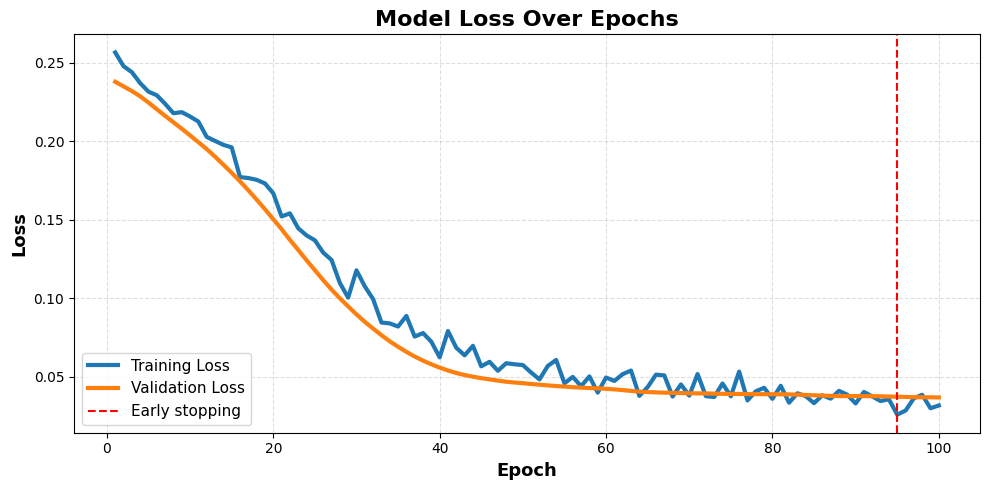

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(history.history["loss"]) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, history.history["loss"],
         label="Training Loss", linewidth=3)
plt.plot(epochs, history.history["val_loss"],
         label="Validation Loss", linewidth=3)

plt.xlabel("Epoch", fontsize=13, weight="bold")
plt.ylabel("Loss", fontsize=13, weight="bold")
plt.title("Model Loss Over Epochs", fontsize=16, weight="bold")
#best_epoch = min(history.history["loss"])
best_epoch = history.history["loss"].index(min(history.history["loss"])) + 1
print(best_epoch)
plt.axvline(
    best_epoch,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Early stopping"
)

plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
#plt.xlim(5, 20)
#plt.ylim(top=0.05)
plt.show()


## Feature Importance Computation
Computes permutation feature importance for a multi-output regression model. The function first calculates a baseline prediction error (mean squared error) for each output using the unmodified input features. Then, for each input feature column, it randomly permutes that feature across samples while keeping all other features unchanged. The model is re-evaluated on this permuted data, and the increase in prediction error relative to the baseline is measured for each output dimension. The resulting importance matrix quantifies how much each input feature contributes to the prediction of each output: larger positive values indicate that permuting the feature degrades model performance, implying higher importance, while values near zero indicate minimal influence.

In [ ]:
# --- Predict ---
y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━

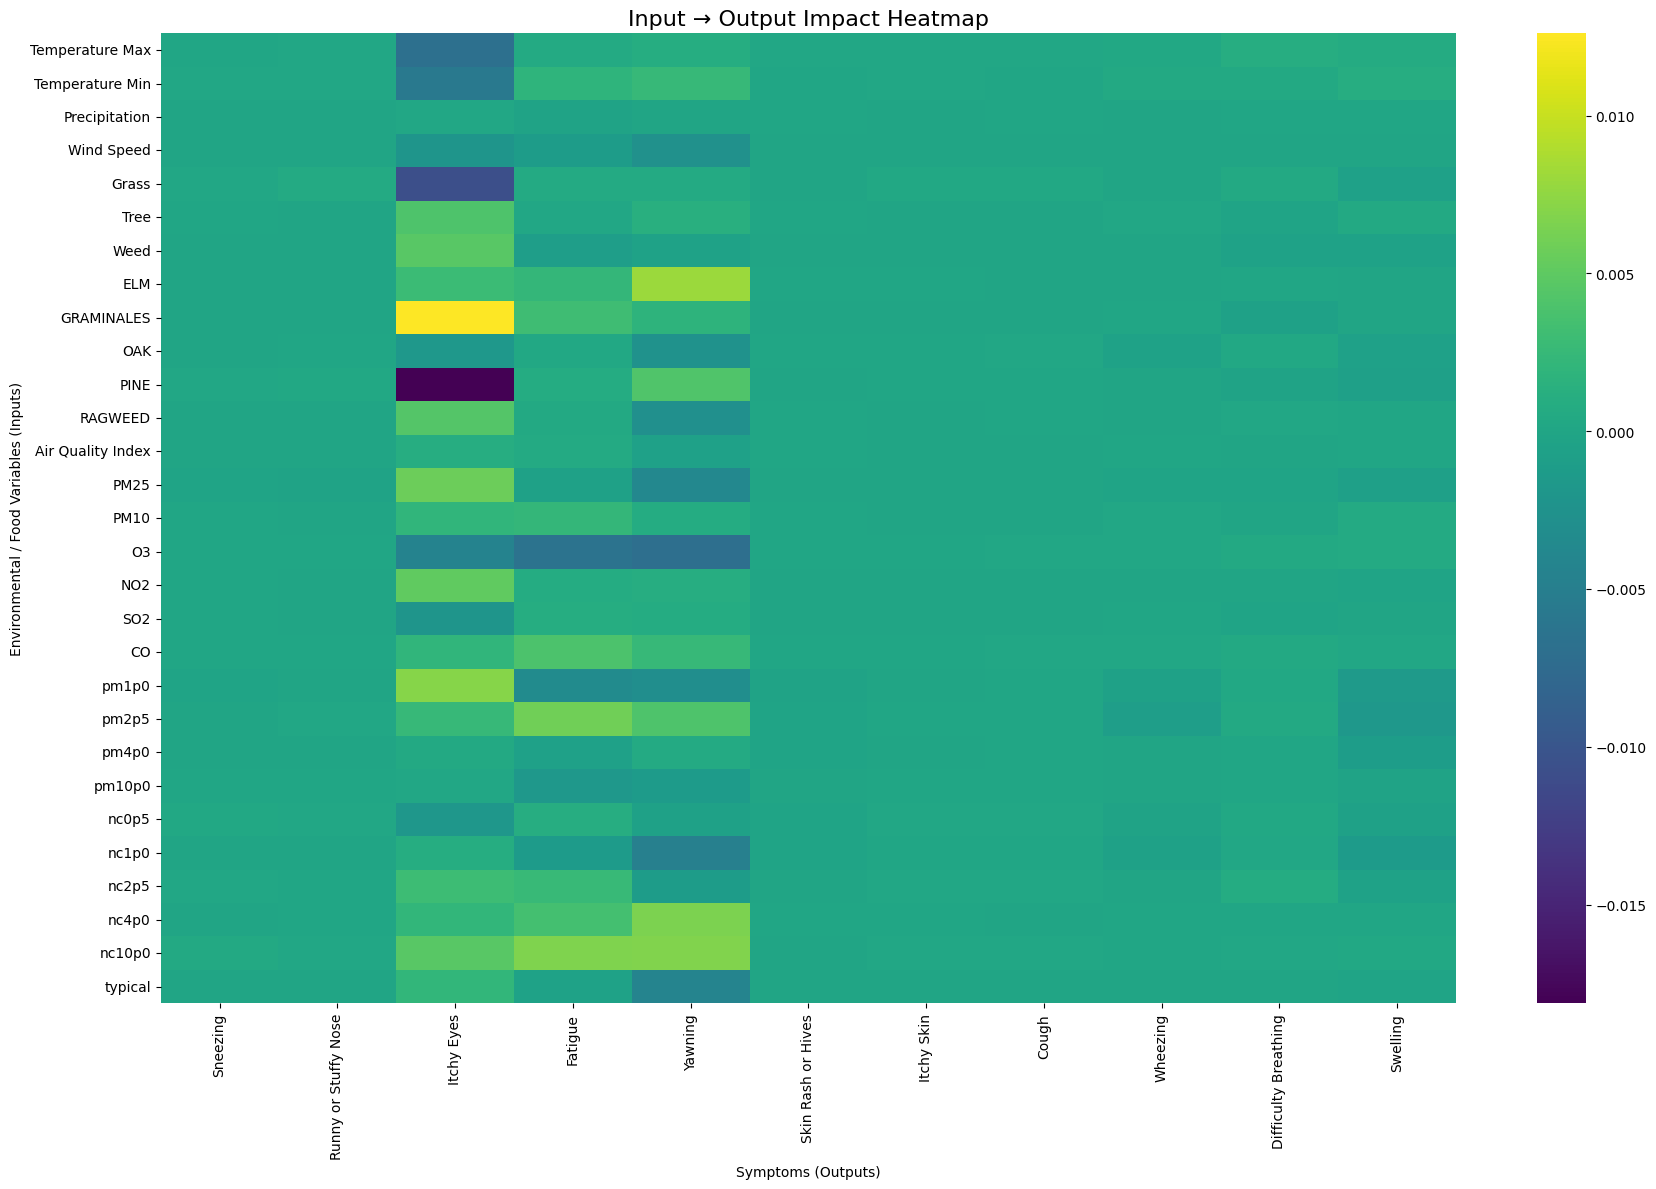

In [ ]:
def permutation_importance_multioutput(model, X, y, outputs):
    """
    Computes permutation feature importance for a multi-output regression model.

    For each input feature, the function randomly permutes its values across samples
    while keeping all other features unchanged. The resulting increase in mean squared
    error (relative to the baseline) is computed separately for each output.

    Parameters
    ----------
    model : trained model
        A fitted multi-output regression model with a predict() method
    X : np.ndarray
        Input feature matrix of shape (n_samples, n_features)
    y : np.ndarray
        True target matrix of shape (n_samples, n_outputs)
    outputs : int
        Number of output variables (symptoms)

    Returns
    -------
    np.ndarray
        Importance matrix of shape (n_features, n_outputs)
    """

    # Baseline predictions and per-output baseline MSE
    baseline_pred = model.predict(X)
    baseline_loss = np.mean((y - baseline_pred) ** 2, axis=0)

    # Initialize importance matrix: rows = features, columns = outputs
    importance_matrix = np.zeros((X.shape[1], outputs))

    # Permute each feature independently
    for i in range(X.shape[1]):
        X_permuted = X.copy()
        np.random.shuffle(X_permuted[:, i])  # shuffle feature i across samples

        permuted_pred = model.predict(X_permuted)
        permuted_loss = np.mean((y - permuted_pred) ** 2, axis=0)

        # Importance = increase in loss caused by permuting the feature
        importance_matrix[i] = permuted_loss - baseline_loss

    return importance_matrix


# ----------------------------
# Compute permutation importance
# ----------------------------
importance = permutation_importance_multioutput(
    model,
    X_test,
    y_test,
    outputs=y_test.shape[1]
)

# ----------------------------
# Convert to labeled DataFrame
# ----------------------------
df_importance = pd.DataFrame(
    importance,
    index=X_cols,   # input feature names
    columns=Y_cols  # output symptom names
)

# Remove features with zero importance for the first output (noise filtering)
df_importance = df_importance[df_importance.iloc[:, 0] != 0]

# ----------------------------
# Visualization
# ----------------------------
plt.figure(figsize=(18, 12))
sns.heatmap(df_importance, cmap="viridis", annot=False)
plt.title("Input → Output Impact Heatmap", fontsize=16)
plt.xlabel("Symptoms (Outputs)")
plt.ylabel("Environmental / Food Variables (Inputs)")
plt.tight_layout()
plt.show()


## Confusion Matrix
**TP — True Positive** - Model correctly predicts the symptom when it is actually present.

**FP — False Positive**- Model predicts the symptom when it is not actually present.

**TN — True Negative** - Model correctly predicts the symptom is not present.

**FN — False Negative** - Model fails to predict the symptom when it is actually present.

**Accuracy** - It measures how often the model’s predictions are correct overall, counting both symptom-present and symptom-absent cases.

It answers:

> “Out of all predictions, how many did the model get right?”



**Recall (Sensitivity)** Proportion of actual symptom cases that the model successfully detects.
High recall means few missed symptoms.
$$
\text{Recall} = \frac{TP}{TP + FN}
$$

It answers:
> "How many predictions are actually true of total actual true cases."

**Precision** Proportion of predicted symptom cases that are actually correct.
High precision means few false alarms.

$$
\text{Precision} = \frac{TP}{TP + FP}
$$
It answers
> How many predictions are actually true of of total true predictions.

**F1 Score** Single metric that balances precision and recall, useful for imbalanced data.

$$
\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}
{\text{Precision} + \text{Recall}}
$$
Another way of looking at it :
$$
\mathrm{F1} = \frac{TP}{TP + \frac{1}{2}(FP + FN)}
$$

![Image1](https://drive.google.com/uc?export=view&id=1rYb-2nfCpp0YCZHYMwS00aLxXPLJ3vne)


In [ ]:
def per_symptom_confusion(y_true, y_pred, Y_cols):
    import pandas as pd
    from sklearn.metrics import confusion_matrix

    # Convert DataFrame → NumPy if needed
    if isinstance(y_true, pd.DataFrame):
        y_true = y_true.values

    rows = []

    for i, symptom in enumerate(Y_cols):
        yt = y_true[:, i]
        yp = y_pred[:, i]

        tn, fp, fn, tp = confusion_matrix(
                yt, yp,
                labels=[0, 1]
            ).ravel()

        precision = tp / (tp + fp) if (tp + fp) else 0
        recall    = tp / (tp + fn) if (tp + fn) else 0

        rows.append({
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "TN": tn,
            "Precision": precision,
            "Recall": recall
        })

    df = pd.DataFrame(rows, index=Y_cols)
    df.index.name = "symptom"
    return df

# If you have continuous predictions:
# Y_hat = multi_reg.predict(X)
Y_pred01 = (y_pred >= 0.08).astype(int)

conf_df = per_symptom_confusion(y_test, Y_pred01, Y_cols)

conf_df["F1"] = (
    2 * conf_df["Precision"] * conf_df["Recall"] /
    (conf_df["Precision"] + conf_df["Recall"])
).fillna(0)

conf_df["Accuracy"] = (
    (conf_df["TP"] + conf_df["TN"]) /
    (conf_df["TP"] + conf_df["TN"] + conf_df["FP"] + conf_df["FN"])
).fillna(0)

conf_df.sort_values("F1", ascending=False)

,TP,FP,FN,TN,Precision,Recall,F1,Accuracy
symptom,,,,,,,,
Itchy Eyes,2,2,1,11,0.500000,0.666667,0.571429,0.8125
Yawning,1,5,0,10,0.166667,1.000000,0.285714,0.6875
Fatigue,1,7,0,8,0.125000,1.000000,0.222222,0.5625
Runny or Stuffy Nose,0,0,0,16,0.000000,0.000000,0.000000,1.0000
Sneezing,0,0,2,14,0.000000,0.000000,0.000000,0.8750
Skin Rash or Hives,0,0,1,15,0.000000,0.000000,0.000000,0.9375
Itchy Skin,0,0,0,16,0.000000,0.000000,0.000000,1.0000
Cough,0,0,0,16,0.000000,0.000000,0.000000,1.0000
Wheezing,0,0,1,15,0.000000,0.000000,0.000000,0.9375


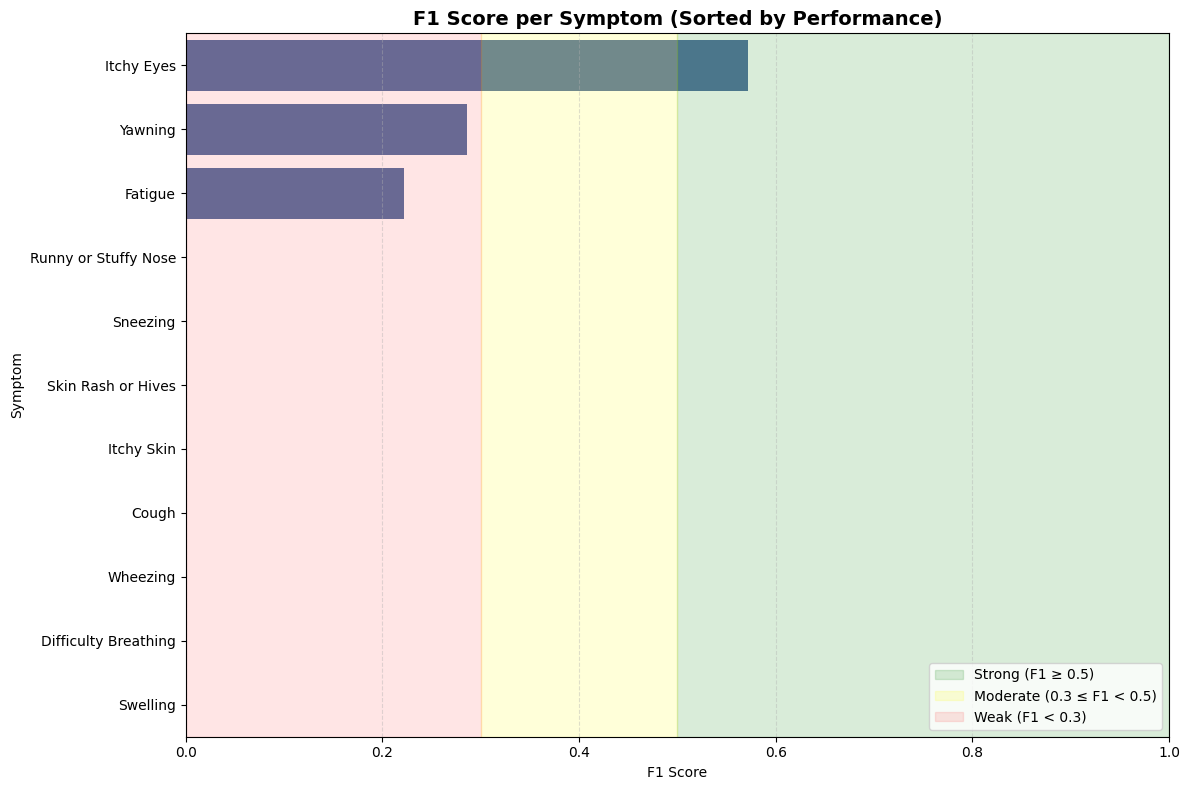

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort by F1 score
conf_sorted = conf_df.sort_values("F1", ascending=False)

plt.figure(figsize=(12, 8))

# Plot horizontal bars
sns.barplot(
    x=conf_sorted["F1"],
    y=conf_sorted.index,
    color="#4c72b0"
)

# Performance bands
plt.axvspan(0.5, 1.0, color="green", alpha=0.15, label="Strong (F1 ≥ 0.5)")
plt.axvspan(0.3, 0.5, color="yellow", alpha=0.15, label="Moderate (0.3 ≤ F1 < 0.5)")
plt.axvspan(0.0, 0.3, color="red", alpha=0.10, label="Weak (F1 < 0.3)")

# Labels & styling
plt.title("F1 Score per Symptom (Sorted by Performance)", fontsize=14, weight="bold")
plt.xlabel("F1 Score")
plt.ylabel("Symptom")
plt.xlim(0, 1)
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()
